In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['Brent Oil Futures Historical Data.csv'].decode('utf-8')))

Saving Brent Oil Futures Historical Data.csv to Brent Oil Futures Historical Data.csv


In [3]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [4]:
# Converting "Vol." column to float datatype
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [5]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-6-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5000 non-null   datetime64[ns]
 1   Price   5000 non-null   float64       
 2   Open    5000 non-null   float64       
 3   High    5000 non-null   float64       
 4   Low     5000 non-null   float64       
 5   Vol.    5000 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 234.5 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

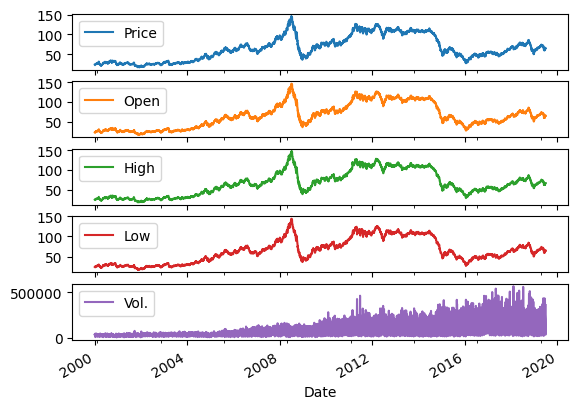

In [8]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [10]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,65.06,65.05,66.75,64.22,361410.0
1,66.55,66.51,66.84,66.08,34620.0
2,66.55,66.05,66.82,65.63,103160.0
3,66.49,65.80,66.85,65.60,141950.0
4,65.05,64.89,65.98,64.17,205800.0
...,...,...,...,...,...
4995,23.73,23.04,23.78,23.04,26390.0
4996,23.09,23.57,23.98,23.05,34830.0
4997,23.62,23.55,24.22,23.35,44660.0
4998,23.73,24.25,24.37,23.70,30310.0


In [11]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,65.320384,65.318124,66.179498,64.419316,134264.877951
std,30.340801,30.326109,30.583107,30.042614,101465.108523
min,17.680000,17.400000,18.050000,16.650000,5180.000000
25%,40.245000,40.235000,40.967500,39.435000,42837.500000
50%,61.830000,61.795000,62.800000,60.920000,109290.000000
75%,87.440000,87.450000,88.725000,86.185000,208082.500000
max,146.080000,146.300000,147.500000,144.250000,567760.000000


In [12]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.36900312, 0.36966641, 0.37620703, 0.37280564, 0.63320772],
       [0.38060748, 0.38099302, 0.37690228, 0.38738245, 0.05233034],
       [0.38060748, 0.37742436, 0.37674778, 0.3838558 , 0.1741619 ],
       ...,
       [0.04626168, 0.0477114 , 0.04766319, 0.05250784, 0.07017669],
       [0.04711838, 0.05314197, 0.04882194, 0.05525078, 0.0446692 ],
       [0.05225857, 0.05042669, 0.05137119, 0.05673981, 0.04857976]])

In [13]:
# Extracting the target variable 
features=data_scaled #attributes include all the columns including the target
target=data_scaled[:,0] #target only the first column = price

In [14]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(features, target, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.36900312, 0.36966641, 0.37620703, 0.37280564, 0.63320772],
         [0.38060748, 0.38099302, 0.37690228, 0.38738245, 0.05233034]]]),
 array([0.38060748]))

In [18]:
# Splitting the dataset in 98% train and 2% test dataset. 
# Shuffle=False because its a time series data
x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.02, random_state=42, shuffle=False)

In [19]:
x_train.shape, x_test.shape

((4900, 5), (100, 5))

In [20]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=32
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [21]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.36900312, 0.36966641, 0.37620703, 0.37280564, 0.63320772],
         [0.38060748, 0.38099302, 0.37690228, 0.38738245, 0.05233034],
         [0.38060748, 0.37742436, 0.37674778, 0.3838558 , 0.1741619 ],
         [0.38014019, 0.37548487, 0.37697953, 0.38362069, 0.24311209]],
 
        [[0.38060748, 0.38099302, 0.37690228, 0.38738245, 0.05233034],
         [0.38060748, 0.37742436, 0.37674778, 0.3838558 , 0.1741619 ],
         [0.38014019, 0.37548487, 0.37697953, 0.38362069, 0.24311209],
         [0.36892523, 0.36842514, 0.37025879, 0.37241379, 0.35660706]],
 
        [[0.38060748, 0.37742436, 0.37674778, 0.3838558 , 0.1741619 ],
         [0.38014019, 0.37548487, 0.37697953, 0.38362069, 0.24311209],
         [0.36892523, 0.36842514, 0.37025879, 0.37241379, 0.35660706],
         [0.36744548, 0.37315749, 0.36879104, 0.37170846, 0.37729745]],
 
        [[0.38014019, 0.37548487, 0.37697953, 0.38362069, 0.24311209],
         [0.36892523, 0.36842514, 0.37025879, 0.37241379, 0.35660706

In [22]:
# LSTM model architecture
model=tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) #LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.LSTM(128, return_sequences=False))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(1))

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [24]:
# Defining the model
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Adam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])

Epoch 1/50


<ipython-input-24-a45389fa3556>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])


153/153 [==============================] - 13s 40ms/step - loss: 0.0197 - mean_absolute_error: 0.1028 - val_loss: 6.0965e-04 - val_mean_absolute_error: 0.0212
Epoch 2/50
153/153 [==============================] - 5s 33ms/step - loss: 0.0186 - mean_absolute_error: 0.1001 - val_loss: 3.2594e-04 - val_mean_absolute_error: 0.0149
Epoch 3/50
153/153 [==============================] - 5s 30ms/step - loss: 0.0141 - mean_absolute_error: 0.0849 - val_loss: 1.1063e-04 - val_mean_absolute_error: 0.0080
Epoch 4/50
153/153 [==============================] - 6s 39ms/step - loss: 0.0079 - mean_absolute_error: 0.0640 - val_loss: 5.6619e-05 - val_mean_absolute_error: 0.0060
Epoch 5/50
153/153 [==============================] - 5s 31ms/step - loss: 0.0031 - mean_absolute_error: 0.0378 - val_loss: 8.6775e-05 - val_mean_absolute_error: 0.0079
Epoch 6/50
153/153 [==============================] - 6s 36ms/step - loss: 0.0018 - mean_absolute_error: 0.0295 - val_loss: 6.9072e-05 - val_mean_absolute_error: 0.0

In [25]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-25-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[6.907153147039935e-05, 0.00692362105473876]

In [26]:
predictions=model.predict_generator(test_generator)

<ipython-input-26-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [27]:
# Test data had 1000 datapoints and 4 win_length hence the prediction shape is 996 
predictions.shape[0]

96

In [28]:
predictions

array([[0.0835214 ],
       [0.08119741],
       [0.0809114 ],
       [0.08299491],
       [0.08442172],
       [0.08376069],
       [0.0833959 ],
       [0.08378066],
       [0.07987747],
       [0.07667264],
       [0.07247122],
       [0.06982218],
       [0.06728058],
       [0.06453867],
       [0.06251336],
       [0.06069408],
       [0.05828933],
       [0.05470987],
       [0.05187505],
       [0.05077172],
       [0.05126875],
       [0.05204851],
       [0.05078258],
       [0.0480096 ],
       [0.04644626],
       [0.04565658],
       [0.04622389],
       [0.04515233],
       [0.04289824],
       [0.04288946],
       [0.0466472 ],
       [0.05140391],
       [0.05389284],
       [0.05539028],
       [0.05818454],
       [0.06018157],
       [0.05998104],
       [0.06060725],
       [0.06324468],
       [0.06637975],
       [0.06667276],
       [0.06623339],
       [0.06499925],
       [0.06579157],
       [0.06804148],
       [0.07239544],
       [0.07789214],
       [0.082

In [29]:
x_test, y_test

(array([[0.08964174, 0.08696664, 0.08613364, 0.09184953, 0.04945074],
        [0.08512461, 0.0799069 , 0.0818849 , 0.08659875, 0.04216289],
        [0.07647975, 0.07835531, 0.07377366, 0.08189655, 0.04401152],
        [0.07593458, 0.08650116, 0.08149865, 0.08260188, 0.06295993],
        [0.08496885, 0.08766486, 0.08613364, 0.09012539, 0.06173344],
        [0.08753894, 0.08223429, 0.08420239, 0.08894984, 0.05958264],
        [0.07951713, 0.08184639, 0.07779065, 0.08597179, 0.04982403],
        [0.0864486 , 0.08502715, 0.0834299 , 0.09169279, 0.0051015 ],
        [0.08294393, 0.07944143, 0.08088065, 0.08487461, 0.02607629],
        [0.08076324, 0.07874321, 0.07979915, 0.08346395, 0.0230545 ],
        [0.07609034, 0.07020946, 0.07377366, 0.0757837 , 0.04054534],
        [0.06806854, 0.07137316, 0.06713017, 0.0757837 , 0.03718582],
        [0.0711838 , 0.06446858, 0.06875241, 0.07100313, 0.04043869],
        [0.06542056, 0.06128782, 0.06257242, 0.06739812, 0.03179992],
        [0.05926791,

In [30]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.08766486, 0.08223429, 0.08184639, 0.08502715, 0.07944143,
       0.07874321, 0.07020946, 0.07137316, 0.06446858, 0.06128782,
       0.06020171, 0.05818464, 0.06012413, 0.05197828, 0.05081458,
       0.04383243, 0.04577192, 0.05003879, 0.04926299, 0.04344453,
       0.04460822, 0.03685027, 0.04305663, 0.04414275, 0.03491078,
       0.03413499, 0.03878976, 0.04615981, 0.05042669, 0.04654771,
       0.05391777, 0.05896043, 0.05740884, 0.05430566, 0.06082234,
       0.06322731, 0.0640031 , 0.0647789 , 0.06167572, 0.06245151,
       0.06051202, 0.06982157, 0.07370054, 0.07602793, 0.08494957,
       0.08999224, 0.08921645, 0.09038014, 0.09270753, 0.10861133,
       0.09852599, 0.08960434, 0.08960434, 0.08766486, 0.08223429,
       0.07719162, 0.07602793, 0.07641583, 0.07447634, 0.07059736,
       0.06555469, 0.06943367, 0.07176106, 0.07564003, 0.07564003,
       0.07602793, 0.0810706 , 0.07835531, 0.07253685, 0.07020946,
       0.07238169, 0.07331265, 0.07176106, 0.06764934, 0.07152

In [31]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-31-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.083521,0.087665,0.086134,0.090125,0.061733
1,0.081197,0.082234,0.084202,0.088950,0.059583
2,0.080911,0.081846,0.077791,0.085972,0.049824
3,0.082995,0.085027,0.083430,0.091693,0.005101
4,0.084422,0.079441,0.080881,0.084875,0.026076
...,...,...,...,...,...
91,0.062064,0.043755,0.044264,0.050078,0.037701
92,0.059052,0.047867,0.045809,0.050157,0.052704
93,0.056119,0.047711,0.047663,0.052508,0.070177
94,0.053637,0.053142,0.048822,0.055251,0.044669


In [32]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[2.84041472e+01, 2.87000000e+01, 2.92000000e+01, 2.81500000e+01,
        3.99100000e+04],
       [2.81057475e+01, 2.80000000e+01, 2.89500000e+01, 2.80000000e+01,
        3.87000000e+04],
       [2.80690235e+01, 2.79500000e+01, 2.81200000e+01, 2.76200000e+01,
        3.32100000e+04],
       [2.83365462e+01, 2.83600000e+01, 2.88500000e+01, 2.83500000e+01,
        8.05000000e+03],
       [2.85197494e+01, 2.76400000e+01, 2.85200000e+01, 2.74800000e+01,
        1.98500000e+04],
       [2.84348731e+01, 2.75500000e+01, 2.83800000e+01, 2.73000000e+01,
        1.81500000e+04],
       [2.83880333e+01, 2.64500000e+01, 2.76000000e+01, 2.63200000e+01,
        2.79900000e+04],
       [2.84374369e+01, 2.66000000e+01, 2.67400000e+01, 2.63200000e+01,
        2.61000000e+04],
       [2.79362666e+01, 2.57100000e+01, 2.69500000e+01, 2.57100000e+01,
        2.79300000e+04],
       [2.75247665e+01, 2.53000000e+01, 2.61500000e+01, 2.52500000e+01,
        2.30700000e+04],
       [2.69853051e+01, 2.5160

In [33]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(      Price   Open   High    Low     Vol.
 4904  28.59  28.70  29.20  28.15  39910.0
 4905  28.92  28.00  28.95  28.00  38700.0
 4906  27.89  27.95  28.12  27.62  33210.0
 4907  28.78  28.36  28.85  28.35   8050.0
 4908  28.33  27.64  28.52  27.48  19850.0
 ...     ...    ...    ...    ...      ...
 4995  23.73  23.04  23.78  23.04  26390.0
 4996  23.09  23.57  23.98  23.05  34830.0
 4997  23.62  23.55  24.22  23.35  44660.0
 4998  23.73  24.25  24.37  23.70  30310.0
 4999  24.39  23.90  24.70  23.89  32510.0
 
 [96 rows x 5 columns],
 Price    96
 Open     96
 High     96
 Low      96
 Vol.     96
 dtype: int64)

In [34]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-34-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
4904,28.59,28.70,29.20,28.15,39910.0,28.404147
4905,28.92,28.00,28.95,28.00,38700.0,28.105748
4906,27.89,27.95,28.12,27.62,33210.0,28.069023
4907,28.78,28.36,28.85,28.35,8050.0,28.336546
4908,28.33,27.64,28.52,27.48,19850.0,28.519749
...,...,...,...,...,...,...
4995,23.73,23.04,23.78,23.04,26390.0,25.648980
4996,23.09,23.57,23.98,23.05,34830.0,25.262250
4997,23.62,23.55,24.22,23.35,44660.0,24.885619
4998,23.73,24.25,24.37,23.70,30310.0,24.567024


<Axes: >

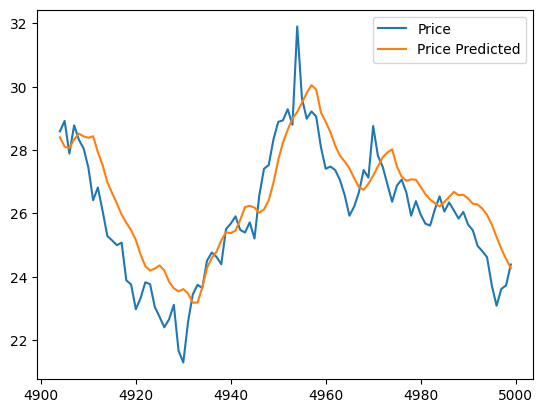

In [35]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [36]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.6 MB/s eta 0:00:00
no display found. Using non-interactive Agg backend


In [37]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : -0.5485
       Root Mean Squared Error (RMSE) : 1.0671
            Mean Absolute Error (MAE) : 0.8890
          Mean Percentage Error (MPE) : -2.2854
Mean Absolute Percentage Error (MAPE) : 3.4930
